In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
X_train = pd.read_csv('./data/X_train.csv', index_col=2)
y_train = pd.read_csv('./data/y_train.csv')
X_test = pd.read_csv('./data/X_test.csv', index_col=2)

X_train

,Дата,Группа,Формат,Размер изображения,Тип устройства,Пол,Категория таргетинга,Упоминание брендов,Уровень платежеспособности,Возраст,Заголовок,Текст
№ Объявления,,,,,,,,,,,,
M-9591367848,19.03.2024,Аккумуляторы Машина,текстовый,без изображения,мобильные,мужской,Целевые запросы,Без упоминания вашего бренда,Остальные,45-54,Выберите авто аккумулятор с выгодой,Аккумуляторы для легковую машину в Иркутске. Д...
M-9591367816,18.09.2023,Аккумуляторы Новый,текстовый,без изображения,мобильные,мужской,не определено,не определено,6-10%,25-34,Новые Аккумуляторы,Centra Market - Большой выбор новых аккумулято...
M-9591367718,07.02.2024,Аккумуляторы Иркутск,текстовый,без изображения,мобильные,мужской,Широкие запросы,не определено,Остальные,старше 55,Большой выбор Авто аккумуляторов,Гарантия. Сервис. Свяжитесь со специалистом ил...
M-9591367860,08.10.2023,Аккумуляторы Купить Цена,графический,с изображением,десктоп,женский,Целевые запросы,не определено,6-10%,35-44,Купить аккумулятор с выгодой,Выгодные цены на аккумуляторы в Иркутске. Дост...
M-9591367826,05.07.2023,Аккумуляторы Магазин,текстовый,без изображения,мобильные,женский,Целевые запросы,не определено,Остальные,35-44,Большой магазин Авто аккумуляторов,Свяжитесь со специалистом или выберите аккумул...
...,...,...,...,...,...,...,...,...,...,...,...,...
M-9591367864,30.11.2023,АКБ,графический,с изображением,десктоп,мужской,Целевые запросы,не определено,Остальные,45-54,Продажа АКБ для авто в Иркутске,Большой выбор АКБ для авто в Иркутске и обл. О...
M-9591367848,19.12.2023,Аккумуляторы Машина,графический,с изображением,десктоп,мужской,Узкие запросы,не определено,Остальные,старше 55,Выберите авто аккумулятор с выгодой,Аккумуляторы для легковую машину в Иркутске. Д...
M-9591367862,01.06.2024,Аккумуляторы Купить Цена,текстовый,без изображения,мобильные,мужской,Узкие запросы,Без упоминания вашего бренда,6-10%,18-24,Низкие цены на Аккумуляторы,Гарантия. Сервис. Доставка. Позвоните нам или ...


<Axes: xlabel='0', ylabel='count'>

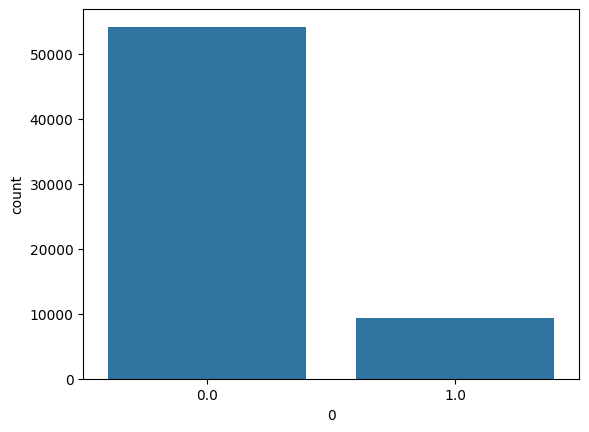

In [90]:
sns.countplot(data=y_train, x="0")

In [91]:
def totypes(df: pd.DataFrame) -> pd.DataFrame:
    df['Дата'] = pd.to_datetime(df['Дата'], format='%d.%m.%Y')
    df['Группа'] = df['Группа'].astype('category')
    df['Формат'] = df['Формат'].astype('category')
    df['Размер изображения'] = df['Размер изображения'].astype('category')
    df['Тип устройства'] = df['Тип устройства'].astype('category')
    df['Пол'] = df['Пол'].astype('category')
    df['Категория таргетинга'] = df['Категория таргетинга'].astype('category')
    df['Упоминание брендов'] = df['Упоминание брендов'].astype('category')
    df['Уровень платежеспособности'] = df['Уровень платежеспособности'].astype('category')
    df['Возраст'] = df['Возраст'].astype('category')
    return df

def fiture_engenering(df: pd.DataFrame) -> pd.DataFrame:
    return df

In [92]:
def pipeline(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.drop(columns=['Заголовок', 'Текст'])
    df = totypes(df)
    return df

X_train = pipeline(X_train)
X_test = pipeline(X_test)
X_train

,Дата,Группа,Формат,Размер изображения,Тип устройства,Пол,Категория таргетинга,Упоминание брендов,Уровень платежеспособности,Возраст
№ Объявления,,,,,,,,,,
M-9591367848,2024-03-19,Аккумуляторы Машина,текстовый,без изображения,мобильные,мужской,Целевые запросы,Без упоминания вашего бренда,Остальные,45-54
M-9591367816,2023-09-18,Аккумуляторы Новый,текстовый,без изображения,мобильные,мужской,не определено,не определено,6-10%,25-34
M-9591367718,2024-02-07,Аккумуляторы Иркутск,текстовый,без изображения,мобильные,мужской,Широкие запросы,не определено,Остальные,старше 55
M-9591367860,2023-10-08,Аккумуляторы Купить Цена,графический,с изображением,десктоп,женский,Целевые запросы,не определено,6-10%,35-44
M-9591367826,2023-07-05,Аккумуляторы Магазин,текстовый,без изображения,мобильные,женский,Целевые запросы,не определено,Остальные,35-44
...,...,...,...,...,...,...,...,...,...,...
M-9591367864,2023-11-30,АКБ,графический,с изображением,десктоп,мужской,Целевые запросы,не определено,Остальные,45-54
M-9591367848,2023-12-19,Аккумуляторы Машина,графический,с изображением,десктоп,мужской,Узкие запросы,не определено,Остальные,старше 55
M-9591367862,2024-06-01,Аккумуляторы Купить Цена,текстовый,без изображения,мобильные,мужской,Узкие запросы,Без упоминания вашего бренда,6-10%,18-24


In [93]:
from catboost import Pool, CatBoostClassifier

cat_features = [col for col in X_train.columns if X_train[col].dtype.name == 'category']

# Initialize CatBoostClassifier (tune parameters as needed)
model = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=100)

# Train using Pool to specify categorical features
train_pool = Pool(data=X_train, label=y_train, cat_features=cat_features)
model.fit(train_pool)

# Predict on X_test using Pool with the same cat features
test_pool = Pool(data=X_test, cat_features=cat_features)
predictions = model.predict(test_pool)

0:	learn: 0.6345808	total: 4.16ms	remaining: 2.07s
100:	learn: 0.3914996	total: 820ms	remaining: 3.24s
200:	learn: 0.3847956	total: 1.69s	remaining: 2.52s
300:	learn: 0.3804369	total: 2.61s	remaining: 1.72s
400:	learn: 0.3772111	total: 3.52s	remaining: 870ms
499:	learn: 0.3739205	total: 4.46s	remaining: 0us


<Axes: xlabel='None', ylabel='count'>

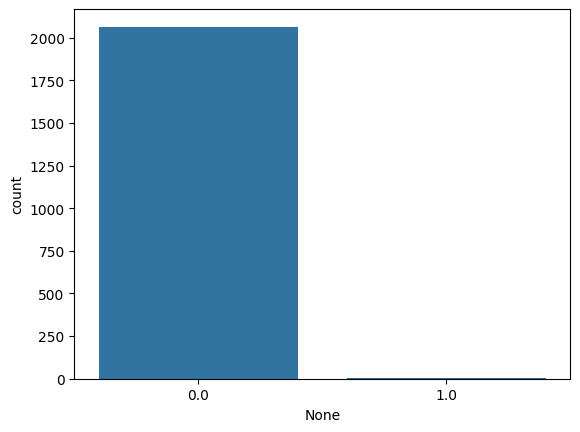

In [94]:
sns.countplot(x=pd.Series(predictions))

In [95]:
pd.Series(predictions, name="0").to_csv('./data/result.csv', index=False)

In [ ]:
zeros_array = np.zeros(1034, dtype=int)
ones_array = np.ones(1034, dtype=int)
result_array = np.concatenate((zeros_array, ones_array))

pd.Series(result_array, name="0").to_csv('./data/result0.csv', index=False)